# Image Classification of Selected Threatened/Endangered Local Mammal Species of Singapore using Neural Networks

### how the hierarchy works:

#### taxon id -- conservation status -- species -- scientific name -- family -- order -- class

43364 CR sunda pangolin -- manis javanica -- manidae -- pholidota (keratin scales) -- mammal




45982 CR red giant flying squirrel -- petaurista petaurista -- sciuridae -- rodentia (rodents) -- mammal




44172 CR east asian/malayan porcupine -- hystrix brachyura -- hystricidae -- rodentia (rodents) -- mammal




922738 CR mainland leopard cat -- prionailurus bengalensis -- felidae -- carnivora -- mammal



41602 CR small-toothed palm civet -- arctogalidia trivirgata -- viverridae -- carnivora -- mammal

41625 CR masked palm civet -- paguma larvata -- viverridae -- carnivora -- mammal

41613 CR large indian civet -- viverra zibetha -- viverridae -- carnivora -- mammal



1638835 CR asian small-clawed otter -- lutra cinera -- mustelidae -- carnivora -- mammal

1638842 EN smooth-coated otter -- lutra perspicillata -- mustelidae -- carnivora -- mammal

https://www.nparks.gov.sg/nature/species-list/terrestrial-mammals
3rd edition of the Singapore Red Data Book (RDB3).

#### focus:
##### identifying critically endangered species in Singapore, with focus on the Sunda Pangolin, the Raffles' Banded Langur, & the Leopard Cat

##### input tensors: 100 images of birds, monkeys, cats, & anteaters
##### target tensors: 100 images classified into its animal type, sub-animal type, & species


#### Imports & Configurations 

In [3]:
# import necessary libraries/dependencies 
import matplotlib.pyplot as plt
import numpy as np
import os
import urllib.request
import PIL
from PIL import Image, ImageOps
from io import BytesIO
# import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
import pathlib
import requests

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [19]:
# # checking if query filters relevant data
# # sunda pangolin
# test_url1 = "https://api.inaturalist.org/v2/observations?taxon_id=43364&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# test_data1 = requests.get(test_url1)
# data1 = test_data1.json()
# print("Sunda Pangolin Status Code, Total Results:", test_data1.status_code, data1["total_results"])

# # red giant flying squirrel
# test_url4 = "https://api.inaturalist.org/v2/observations?taxon_id=45982&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# test_data4 = requests.get(test_url4)
# data4 = test_data4.json()
# print("Red Giant Flying Squirrel Status Code, Total Results:", test_data4.status_code, data4["total_results"])

# # east asian/malayan porcupine
# test_url7 = "https://api.inaturalist.org/v2/observations?taxon_id=44172&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# test_data7 = requests.get(test_url7)
# data7 = test_data7.json()
# print("East Asian/Malayan Porcupine Status Code, Total Results:", test_data7.status_code, data7["total_results"])

# # mainland leopard cat
# test_url8 = "https://api.inaturalist.org/v2/observations?taxon_id=922738&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# test_data8 = requests.get(test_url8)
# data8 = test_data8.json()
# print("Mainland Leopard Cat Status Code, Total Results:", test_data8.status_code, data8["total_results"])

# # small-toothed palm civet
# test_url9 = "https://api.inaturalist.org/v2/observations?taxon_id=41602&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# test_data9 = requests.get(test_url9)
# data9 = test_data9.json()
# print("Small-toothed Palm Civet Status Code, Total Results:", test_data9.status_code, data9["total_results"])

# # masked palm civet
# test_url10 = "https://api.inaturalist.org/v2/observations?taxon_id=41625&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# test_data10 = requests.get(test_url10)
# data10 = test_data10.json()
# print("Masked Palm Civet Status Code, Total Results:", test_data10.status_code, data10["total_results"])

# # large indian civet
# test_url12 = "https://api.inaturalist.org/v2/observations?taxon_id=41613&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# test_data12 = requests.get(test_url12)
# data12 = test_data12.json()
# print("Large Indian Civet Status Code, Total Results:", test_data12.status_code, data12["total_results"])

# # asian small-clawed otter
# test_url13 = "https://api.inaturalist.org/v2/observations?taxon_id=1638835&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# test_data13 = requests.get(test_url13)
# data13 = test_data13.json()
# print("Asian Small-clawed Otter Status Code, Total Results:", test_data13.status_code, data13["total_results"])

# # smooth-coated otter
# test_url14 = "https://api.inaturalist.org/v2/observations?taxon_id=1638842&place_id=57241,162124&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# test_data14 = requests.get(test_url14)
# data14 = test_data14.json()
# print("Smooth-coated Otter Status Code, Total Results:", test_data14.status_code, data14["total_results"])

#### since some species have too few images to work with due to restrictions with the area (species not spotted in Singapore/too few sightings), change project to focus on selected mammals from singapore, but are spotted elsewhere (SEA)

species selection --> based on Singapore's conservation relevance

image dataset --> iNaturalist observations from a wider range of area (geographic)

model objective --> distinguish select mammal species

one limitation may be the background (area in which animal is spotted); distribution/domain difference

since excluded the red-cheeked flying squirrel, the horsfield's flying squirrel, the shew-faced ground squirrel, the brown spiny rat, & the malay civet as the available observations on iNaturalist is not enough for eventually training the model

## Prepare ML Model Skeleton

In [4]:
# list of dictionaries for the species
# taxon id -- conservation status -- species -- scientific name -- family -- order

species_list = [
                    {
                        "species_name": "sunda pangolin",
                        "scientific_name": "manis javanica",
                        "animal_family": "manidae",
                        "animal_order": "pholidota",
                        "taxon_id": 43364,
                        "conservation_status": "CR",
                        "usable_count": 108
                    },
                    {
                        "species_name": "red giant flying squirrel",
                        "scientific_name": "petaurista petaurista",
                        "animal_family": "sciuridae",
                        "animal_order": "rodentia",
                        "taxon_id": 45982,
                        "conservation_status": "CR",
                        "usable_count": 39
                    },
                    {
                        "species_name": "east asian/malayan porcupine",
                        "scientific_name": "hystrix brachyura",
                        "animal_family": "hystricidae",
                        "animal_order": "rodentia",
                        "taxon_id": 44172,
                        "conservation_status": "CR",
                        "usable_count": 422
                    },
                    {
                        "species_name": "mainland leopard cat",
                        "scientific_name": "prionailurus bengalensis",
                        "animal_family": "felidae",
                        "animal_order": "carnivora",
                        "taxon_id": 922738,
                        "conservation_status": "CR",
                        "usable_count": 156 
                    },
                    {
                        "species_name": "small-tooth palm civet",
                        "scientific_name": "arctogalidia trivirgata",
                        "animal_family": "viverridae",
                        "animal_order": "carnivora",
                        "taxon_id": 41602,
                        "conservation_status": "CR",
                        "usable_count": 82  
                    },
                    {
                        "species_name": "masked palm civet",
                        "scientific_name": "paguma larvata",
                        "animal_family": "viverridae",
                        "animal_order": "carnivora",
                        "taxon_id": 41625,
                        "conservation_status": "CR",
                        "usable_count": 80  
                    },
                    {
                        "species_name": "large indian civet",
                        "scientific_name": "viverra zibetha",
                        "animal_family": "viverridae",
                        "animal_order": "carnivora",
                        "taxon_id": 41613,
                        "conservation_status": "CR",
                        "usable_count": 40  
                    },
                    {
                        "species_name": "asian small-clawed otter",
                        "scientific_name": "lutra cinera",
                        "animal_family": "mustelidae",
                        "animal_order": "carnivora",
                        "taxon_id": 1638835,
                        "conservation_status": "CR",
                        "usable_count": 90  
                    },
                    {
                        "species_name": "smooth-coated otter",
                        "scientific_name": "lutra perspicillata",
                        "animal_family": "mustelidae",
                        "animal_order": "carnivora",
                        "taxon_id": 1638842,
                        "conservation_status": "EN",
                        "usable_count": 1835  
                    }
                ]

for animal in species_list:
    print(animal["species_name"], animal["usable_count"])

sunda pangolin 108
red giant flying squirrel 39
east asian/malayan porcupine 422
mainland leopard cat 156
small-tooth palm civet 82
masked palm civet 80
large indian civet 40
asian small-clawed otter 90
smooth-coated otter 1835


#### We will now test the above with 3 observations

In [5]:
# resize & convert image to 80 x 80, rgb
def resize_photo(images):
    images = images.convert("RGB")
    target_size = (80, 80)

    padded_imgs = ImageOps.pad(images, 
                              target_size, 
                              color = "white", 
                              centering = (0.5, 0.5))

    return padded_imgs

In [6]:
# convert images to arrays
def img_to_arr(padded_imgs):
    imgs_arr = np.array(padded_imgs)

    print(imgs_arr.shape)

    return imgs_arr

In [7]:
# normalise images to [0, 1]
def normal_img(imgs_arr):
    imgs_arr = imgs_arr.astype("float32")
    imgs_arr /= 255.0

    return imgs_arr

In [8]:
# flatten 3D tensor into a 1D tensor
def flatten_arr(imgs_arr):
    flattened_arrs = imgs_arr.flatten()

    return flattened_arrs

In [9]:
# API request with dict key
def req_api(animal):
    page_index = 1 # first page is 1, not 0
    collected_obs = [] # for collecting observations
    max_obs = 20 # max. number of observations to collect

    url = f"https://api.inaturalist.org/v2/observations?photos=true&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"

    # while the no. of collected observations is lesser than delcared max.
    while len(collected_obs) < max_obs:
        query_params = {"taxon_id": animal["taxon_id"], "page": page_index} 
        
        # GET request to URL
        response = requests.get(url, params = query_params)
        data = response.json()
        
        page_results = data["results"]

        if not page_results: # no more available observations on page
            break

        collected_obs += page_results # append observation (results) into empty list

        print("Page Number:", page_index,
             "| Retrieved:", len(page_results),
             "| Total Observations Collected:", len(collected_obs)
             )
        
        page_index += 1 # go to the next page

    trim_obs = collected_obs[:max_obs] # trim total no. of observations collected to previously set max.
    del collected_obs[max_obs:]

    print(
        "Animal:", animal["species_name"],
        "| Final Observations:", len(trim_obs)
    )
    return trim_obs

# tag a number to an animal order
int_to_order = {
    0: "pholidota",
    1: "rodentia",
    2: "carnivora"
}

# tag an animal order to the numbers in int_to_order
order_to_int = {
    v: k for k, v in int_to_order.items()
}

# empty lists for converting animal orders to int
x_order = []
y_order = []

for animal in species_list:
    animal_info = req_api(animal)
    observations = animal_info

    animal_order = animal["animal_order"]
    order_int = order_to_int[animal_order]

    print(
        "\nProcessing:", animal["species_name"],
        "| Images:", len(observations),
        "| Order:", order_int
    )
    
    # display & preprocessing images
    for observation in observations:
        if not observation["photos"]: # photo from each observation
            continue

        photo_info = observation["photos"][0]
    
        if "url" not in photo_info:
            continue

        # first resizing of images
        new_url = photo_info["url"].replace("square", "medium")

        try:
            # download image
            img_response = requests.get(new_url)

            if img_response.status_code != 200:
                continue

            images = Image.open(BytesIO(img_response.content)) # load images
            
            rs_observation = resize_photo(images)
            obs_arr = img_to_arr(rs_observation)
            normalised = normal_img(obs_arr)
            flat = flatten_arr(normalised)
    
            if flat.shape != (19200, ):
                continue
            
            x_order.append(flat) # append flattened vector into x_order
            y_order.append(order_int) # append order classification into y_order

        except Exception as e:
            print("Skipped Image:", e)

# convert lists to NumPy arrays after collection of observation's finished
x_order_arr = np.array(x_order, dtype = "float32")
y_order_arr = np.array(y_order, dtype = "int32")

print("\nFinal Order Dataset")
print("X shape:", x_order_arr.shape)
print("Y shape:", y_order_arr.shape)

print(
    "Pholidota:", np.sum(y_order_arr == 0),
    "Rodentia:", np.sum(y_order_arr == 1),
    "Carnivora:", np.sum(y_order_arr == 2)
)

Page Number: 1 | Retrieved: 30 | Total Observations Collected: 30
Animal: sunda pangolin | Final Observations: 20

Processing: sunda pangolin | Images: 20 | Order: 0
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
Page Number: 1 | Retrieved: 30 | Total Observations Collected: 30
Animal: red giant flying squirrel | Final Observations: 20

Processing: red giant flying squirrel | Images: 20 | Order: 1
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
Page Number: 1 | Retrieved: 30 | Total Observations Collected: 30
Animal: east asian/malayan porcupine | Final Observations: 20

Processing: east asian/malayan porcup

### Training / Validation / Test Split

Total images used: 180 (9 species x 20 images each)

- 70% training --> 126 images
- 15% validation --> 27 images
- 15% test --> 27 images

Sampling Technique: Stratify()
- ensure that the distribution of samples across different classes/categories remains representative of the population
    - samples are randomly selected from each group in proportion to their representation in the population ==> reduces the potential for bias in the analysis
- maintains the proportion of different classes 

In [38]:
# splitting dataset for training / testing

x_train, x_temp, y_train, y_temp = train_test_split(x_order_arr, 
                                                    y_order_arr, 
                                                    test_size = 0.3, 
                                                    stratify = y_order_arr)

x_val, x_test, y_val, y_test = train_test_split(x_temp, 
                                                y_temp, 
                                                test_size = 0.5, 
                                                stratify = y_temp)

In [39]:
# precision metrics for each class (for later)
# metrics_list = [
#     tf.keras.metrics.Precision(class_id = i, name = f"precision_{int_to_order[i]}") for i in range(len(order_to_int))
# ]

In [40]:
# ML model
model = tf.keras.Sequential([
    keras.Input(shape = (19200, )),
    layers.Dense(64, activation = "relu"),
    layers.Dropout(0.5),
    layers.Dense(3, activation = "softmax")
])

# compile model
model.compile(
    optimizer = keras.optimizers.AdamW(),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
    # metrics = metrics_list
)

# fit model
model.fit(
    x = x_train,
    y = y_train,
    batch_size = 16,
    epochs = 50,
    validation_data = (x_val, y_val)
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 5.8539 - sparse_categorical_accuracy: 0.5317 - val_loss: 1.2637 - val_sparse_categorical_accuracy: 0.5926
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.4732 - sparse_categorical_accuracy: 0.4762 - val_loss: 1.0271 - val_sparse_categorical_accuracy: 0.6667
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.1107 - sparse_categorical_accuracy: 0.6429 - val_loss: 1.0961 - val_sparse_categorical_accuracy: 0.6667
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0945 - sparse_categorical_accuracy: 0.6667 - val_loss: 1.0921 - val_sparse_categorical_accuracy: 0.6667
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.0901 - sparse_categorical_accuracy: 0.6667 - val_loss: 1.0876 - val_sparse_categorical_accuracy: 0.6667
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0857 - sparse_categorical_accuracy: 0.6667 - val_loss: 1.0827 - val_sparse_categorical_accuracy: 0.6667
Epoch 7/50
8/8 ━━━━━━━

In [41]:
# test to see if the model is predicting that all animals are in the carnivora order (index 2)
x_val2 = model.predict(x_val)
print(x_val2.shape)
# x_val = tf.keras.layers.Softmax(x_val)
np.argmax(x_val2, axis = 1) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
(27, 3)


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2])

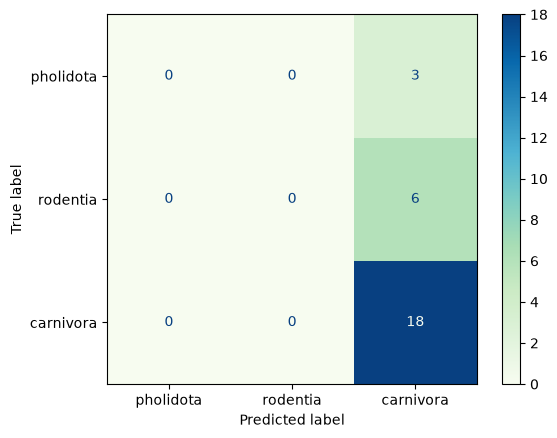

In [42]:
# build confusion matrix
y_pred = np.argmax(x_val2, axis = 1)
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = order_to_int)
disp.plot(cmap = "GnBu")
plt.show()

In [43]:
# classification report
classification_report(y_val, y_pred, zero_division = "warn", output_dict = True)

C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

{'0': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3.0},
 '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 6.0},
 '2': {'precision': 0.6666666666666666,
  'recall': 1.0,
  'f1-score': 0.8,
  'support': 18.0},
 'accuracy': 0.6666666666666666,
 'macro avg': {'precision': 0.2222222222222222,
  'recall': 0.3333333333333333,
  'f1-score': 0.26666666666666666,
  'support': 27.0},
 'weighted avg': {'precision': 0.4444444444444444,
  'recall': 0.6666666666666666,
  'f1-score': 0.5333333333333333,
  'support': 27.0}}

In [44]:
# estimate class weights (dataset is unbalanced)
data_balance = compute_class_weight(class_weight = "balanced", classes = np.unique(y_train), y = y_train)
print(data_balance)

[3.  1.5 0.5]


In [45]:
classes = np.unique(y_train)

db_results = {int(k): float(v) for k, v in zip(classes, data_balance)}
print(db_results)

{0: 3.0, 1: 1.5, 2: 0.5}


In [49]:
# new model with class weights
# ML model
weighted_model = tf.keras.Sequential([
    keras.Input(shape = (19200, )),
    layers.Dense(64, activation = "relu"),
    layers.Dropout(0.5),
    layers.Dense(3, activation = "softmax")
])

# compile model
weighted_model.compile(
    optimizer = keras.optimizers.AdamW(),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
    # metrics = metrics_list
)

weighted_hist = weighted_model.fit(
                    x = x_train,
                    y = y_train,
                    batch_size = 16,
                    epochs = 50,
                    validation_data = (x_val, y_val),
                    class_weight = db_results
                )

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 7.9603 - sparse_categorical_accuracy: 0.3889 - val_loss: 2.0209 - val_sparse_categorical_accuracy: 0.5185
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4.6868 - sparse_categorical_accuracy: 0.3889 - val_loss: 3.0763 - val_sparse_categorical_accuracy: 0.5185
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.8762 - sparse_categorical_accuracy: 0.4048 - val_loss: 1.2590 - val_sparse_categorical_accuracy: 0.2222
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4676 - sparse_categorical_accuracy: 0.2222 - val_loss: 1.1199 - val_sparse_categorical_accuracy: 0.2222
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.0788 - sparse_categorical_accuracy: 0.2302 - val_loss: 1.1308 - val_sparse_categorical_accuracy: 0.1481
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.9787 - sparse_categorical_accuracy: 0.2143 - val_loss: 1.1713 - val_sparse_categorical_accuracy: 0.1852
Epoch 7/50
8/8 ━━━━━━━

In [50]:
# test to see if the model is predicting that all animals are in the carnivora order (index 2)
x_val2 = weighted_model.predict(x_val)
print(x_val2.shape)
# x_val = tf.keras.layers.Softmax(x_val)
np.argmax(x_val2, axis = 1) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
(27, 3)


array([2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2])

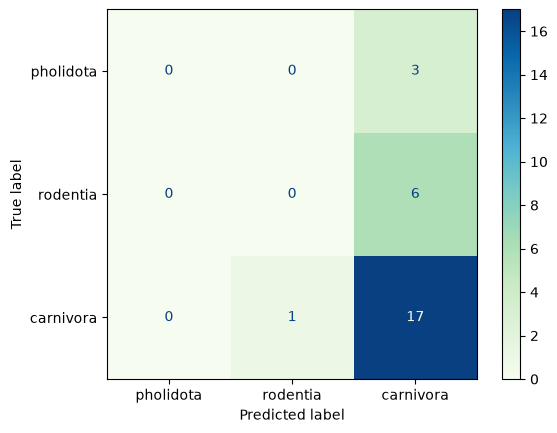

In [51]:
# build confusion matrix
y_pred = np.argmax(x_val2, axis = 1)
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = order_to_int)
disp.plot(cmap = "GnBu")
plt.show()

In [52]:
# classification report
classification_report(y_val, y_pred, zero_division = "warn", output_dict = True)

C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

{'0': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3.0},
 '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 6.0},
 '2': {'precision': 0.6538461538461539,
  'recall': 0.9444444444444444,
  'f1-score': 0.7727272727272727,
  'support': 18.0},
 'accuracy': 0.6296296296296297,
 'macro avg': {'precision': 0.21794871794871795,
  'recall': 0.3148148148148148,
  'f1-score': 0.25757575757575757,
  'support': 27.0},
 'weighted avg': {'precision': 0.4358974358974359,
  'recall': 0.6296296296296297,
  'f1-score': 0.5151515151515151,
  'support': 27.0}}

### Dropout has been lowered to 0.1

In [65]:
# new model but changed dropout
# ML model
low_do_model = tf.keras.Sequential([
    keras.Input(shape = (19200, )),
    layers.Dense(64, activation = "relu"),
    layers.Dropout(0.1),
    layers.Dense(3, activation = "softmax")
])

# compile model
low_do_model.compile(
    optimizer = keras.optimizers.AdamW(),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
    # metrics = metrics_list
)

low_do_hist = low_do_model.fit(
                    x = x_train,
                    y = y_train,
                    batch_size = 16,
                    epochs = 50,
                    validation_data = (x_val, y_val),
                    class_weight = db_results
                )

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 8.2120 - sparse_categorical_accuracy: 0.2778 - val_loss: 1.1188 - val_sparse_categorical_accuracy: 0.5556
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.7133 - sparse_categorical_accuracy: 0.3968 - val_loss: 1.3569 - val_sparse_categorical_accuracy: 0.1852
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 1.3555 - sparse_categorical_accuracy: 0.2460 - val_loss: 1.0857 - val_sparse_categorical_accuracy: 0.3704
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.0256 - sparse_categorical_accuracy: 0.5873 - val_loss: 0.9864 - val_sparse_categorical_accuracy: 0.6296
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 1.0727 - sparse_categorical_accuracy: 0.4286 - val_loss: 1.2523 - val_sparse_categorical_accuracy: 0.1481
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.0532 - sparse_categorical_accuracy: 0.2698 - val_loss: 1.0928 - val_sparse_categorical_accuracy: 0.3704
Epoch 7/50
8/8 ━━━━━━━

In [66]:
# test to see if the model is predicting that all animals are in the carnivora order (index 2)
x_val2 = weighted_model.predict(x_val)
print(x_val2.shape)
# x_val = tf.keras.layers.Softmax(x_val)
np.argmax(x_val2, axis = 1) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
(27, 3)


array([2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2])

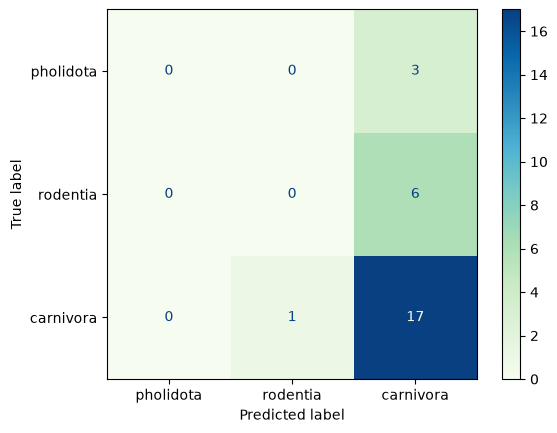

In [67]:
# build confusion matrix
y_pred = np.argmax(x_val2, axis = 1)
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = order_to_int)
disp.plot(cmap = "GnBu")
plt.show()

In [68]:
# classification report
classification_report(y_val, y_pred, zero_division = "warn", output_dict = True)

C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

{'0': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3.0},
 '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 6.0},
 '2': {'precision': 0.6538461538461539,
  'recall': 0.9444444444444444,
  'f1-score': 0.7727272727272727,
  'support': 18.0},
 'accuracy': 0.6296296296296297,
 'macro avg': {'precision': 0.21794871794871795,
  'recall': 0.3148148148148148,
  'f1-score': 0.25757575757575757,
  'support': 27.0},
 'weighted avg': {'precision': 0.4358974358974359,
  'recall': 0.6296296296296297,
  'f1-score': 0.5151515151515151,
  'support': 27.0}}

### Dropout has been increased to 0.3

In [69]:
# new model but changed dropout
# ML model
low_do_model2 = tf.keras.Sequential([
    keras.Input(shape = (19200, )),
    layers.Dense(64, activation = "relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation = "softmax")
])

# compile model
low_do_model2.compile(
    optimizer = keras.optimizers.AdamW(),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
    # metrics = metrics_list
)

low_do_hist2 = low_do_model2.fit(
                    x = x_train,
                    y = y_train,
                    batch_size = 16,
                    epochs = 50,
                    validation_data = (x_val, y_val),
                    class_weight = db_results
                )

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 5.6753 - sparse_categorical_accuracy: 0.3492 - val_loss: 2.0596 - val_sparse_categorical_accuracy: 0.6296
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 3.0136 - sparse_categorical_accuracy: 0.5159 - val_loss: 1.2585 - val_sparse_categorical_accuracy: 0.3704
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.2159 - sparse_categorical_accuracy: 0.4603 - val_loss: 1.0481 - val_sparse_categorical_accuracy: 0.3704
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 1.0630 - sparse_categorical_accuracy: 0.3651 - val_loss: 0.9552 - val_sparse_categorical_accuracy: 0.5556
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 1.0761 - sparse_categorical_accuracy: 0.2381 - val_loss: 1.1535 - val_sparse_categorical_accuracy: 0.1111
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.0896 - sparse_categorical_accuracy: 0.1349 - val_loss: 1.0765 - val_sparse_categorical_accuracy: 0.2222
Epoch 7/50
8/8 ━━━━━━━

In [70]:
# test to see if the model is predicting that all animals are in the carnivora order (index 2)
x_val2 = weighted_model.predict(x_val)
print(x_val2.shape)
# x_val = tf.keras.layers.Softmax(x_val)
np.argmax(x_val2, axis = 1) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
(27, 3)


array([2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2])

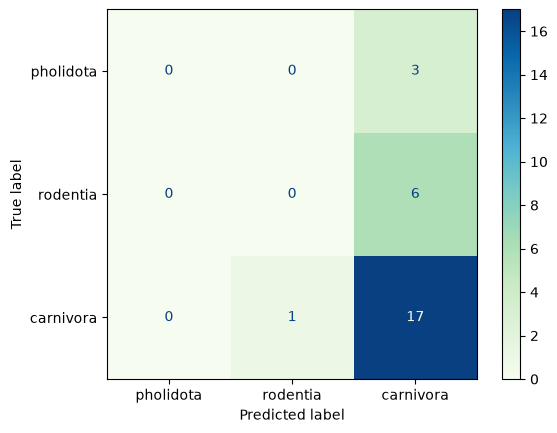

In [71]:
# build confusion matrix
y_pred = np.argmax(x_val2, axis = 1)
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = order_to_int)
disp.plot(cmap = "GnBu")
plt.show()

In [72]:
# classification report
classification_report(y_val, y_pred, zero_division = "warn", output_dict = True)

C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jacmy\anaconda3\envs\tf-coursework\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

{'0': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3.0},
 '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 6.0},
 '2': {'precision': 0.6538461538461539,
  'recall': 0.9444444444444444,
  'f1-score': 0.7727272727272727,
  'support': 18.0},
 'accuracy': 0.6296296296296297,
 'macro avg': {'precision': 0.21794871794871795,
  'recall': 0.3148148148148148,
  'f1-score': 0.25757575757575757,
  'support': 27.0},
 'weighted avg': {'precision': 0.4358974358974359,
  'recall': 0.6296296296296297,
  'f1-score': 0.5151515151515151,
  'support': 27.0}}

In [74]:
# finding pholidota & rodentia positions
pholidota_indices = np.where(y_train == 0)[0]
rodentia_indices = np.where(y_train == 1)[0]

print(pholidota_indices)
print(rodentia_indices)

[ 12  20  28  36  38  46  47  53  63  90  98 102 119 121]
[  2   6  14  16  30  33  34  37  41  43  45  52  55  56  61  62  67  69
  71  80  81  82  97 103 106 109 111 117]
